In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── LOAD DATA ──────────────────────────────────────────
market  = pd.read_csv("../data/raw/market_data.csv",  index_col=0, parse_dates=True)
macro   = pd.read_csv("../data/raw/macro_fred.csv",   index_col=0, parse_dates=True)
rbi     = pd.read_csv("../data/raw/rbi_repo.csv",     index_col=0, parse_dates=True)
events  = pd.read_csv("../data/raw/geopolitical_events.csv", parse_dates=["date"])

# ── MERGE INTO MASTER DATAFRAME ────────────────────────
df = market.copy()
df = df.join(macro.resample("D").ffill(), how="left")
df = df.join(rbi, how="left")
df.ffill(inplace=True)
df.dropna(subset=["USDINR"], inplace=True)

In [3]:
# ── FEATURE ENGINEERING ────────────────────────────────
# 1. Daily returns for each asset
for col in ["USDINR", "NIFTY", "GOLD", "CRUDE", "DXY"]:
    df[f"{col}_ret"] = df[col].pct_change() * 100

# 2. INR rolling volatility (30-day standard deviation of returns)
df["INR_vol_30d"] = df["USDINR_ret"].rolling(30).std()

# 3. US-India interest rate spread (higher spread → INR pressure)
df["Rate_Spread"] = df["US_FEDFUNDS"] - df["RBI_REPO"]

# 4. Geopolitical tension binary indicator
# Mark 1 on event day and 5 trading days after (tension lingers)
df["Geo_Tension"] = 0
for _, row in events.iterrows():
    event_date = row["date"]
    mask = (df.index >= event_date) & (df.index <= event_date + pd.Timedelta(days=7))
    df.loc[mask, "Geo_Tension"] = 1

# 5. Month and Year for seasonal analysis
df["Month"] = df.index.month
df["Year"]  = df.index.year

df.to_csv("../data/processed/master_df.csv")
print(f"Master dataframe: {df.shape}")
print(df.tail(3))

Master dataframe: (2971, 20)
               USDINR         NIFTY   INDIAVIX         GOLD      CRUDE  \
2026-05-20  96.565804  23659.000000  18.440001  4531.299805  98.260002   
2026-05-21  96.528297  23654.699219  17.820000  4539.799805  96.349998   
2026-05-22  96.173897  23719.300781  17.910000  4521.000000  96.599998   

                  DXY   US_CPI  US_FEDFUNDS  US_10Y  RBI_REPO  USDINR_ret  \
2026-05-20  99.110001  332.407         3.64    4.32      5.75    0.307053   
2026-05-21  99.190002  332.407         3.64    4.32      5.75   -0.038840   
2026-05-22  99.320000  332.407         3.64    4.32      5.75   -0.367147   

            NIFTY_ret  GOLD_ret  CRUDE_ret   DXY_ret  INR_vol_30d  \
2026-05-20   0.173596  0.554779  -8.824343 -0.191342     0.645127   
2026-05-21  -0.018178  0.187584  -1.943826  0.080720     0.629863   
2026-05-22   0.273102 -0.414111   0.259471  0.131059     0.636809   

            Rate_Spread  Geo_Tension  Month  Year  
2026-05-20        -2.11            0

In [4]:
# ── STATIONARITY DIAGNOSTICS (ADF TESTS) ────────────────
from statsmodels.tsa.stattools import adfuller

print("=== AUGMENTED DICKEY-FULLER (ADF) TEST ===")
# Resample to monthly averages for forecasting diagnosis
monthly_diag = df[["USDINR","CRUDE","DXY","Rate_Spread"]].resample("ME").mean().dropna()

for col in monthly_diag.columns:
    lvl_res = adfuller(monthly_diag[col])
    diff_res = adfuller(monthly_diag[col].diff().dropna())
    print(f"\n{col}:")
    print(f"  Raw Level:        ADF Stat = {lvl_res[0]:.4f}, p-value = {lvl_res[1]:.4f} (Stationary: {lvl_res[1] < 0.05})")
    print(f"  First Difference: ADF Stat = {diff_res[0]:.4f}, p-value = {diff_res[1]:.4f} (Stationary: {diff_res[1] < 0.05})")

=== AUGMENTED DICKEY-FULLER (ADF) TEST ===

USDINR:
  Raw Level:        ADF Stat = 0.7732, p-value = 0.9912 (Stationary: False)
  First Difference: ADF Stat = -9.9679, p-value = 0.0000 (Stationary: True)

CRUDE:
  Raw Level:        ADF Stat = -2.2285, p-value = 0.1961 (Stationary: False)
  First Difference: ADF Stat = -8.0772, p-value = 0.0000 (Stationary: True)

DXY:
  Raw Level:        ADF Stat = -2.6976, p-value = 0.0745 (Stationary: False)
  First Difference: ADF Stat = -8.1732, p-value = 0.0000 (Stationary: True)

Rate_Spread:
  Raw Level:        ADF Stat = -2.0064, p-value = 0.2838 (Stationary: False)
  First Difference: ADF Stat = -3.6718, p-value = 0.0045 (Stationary: True)


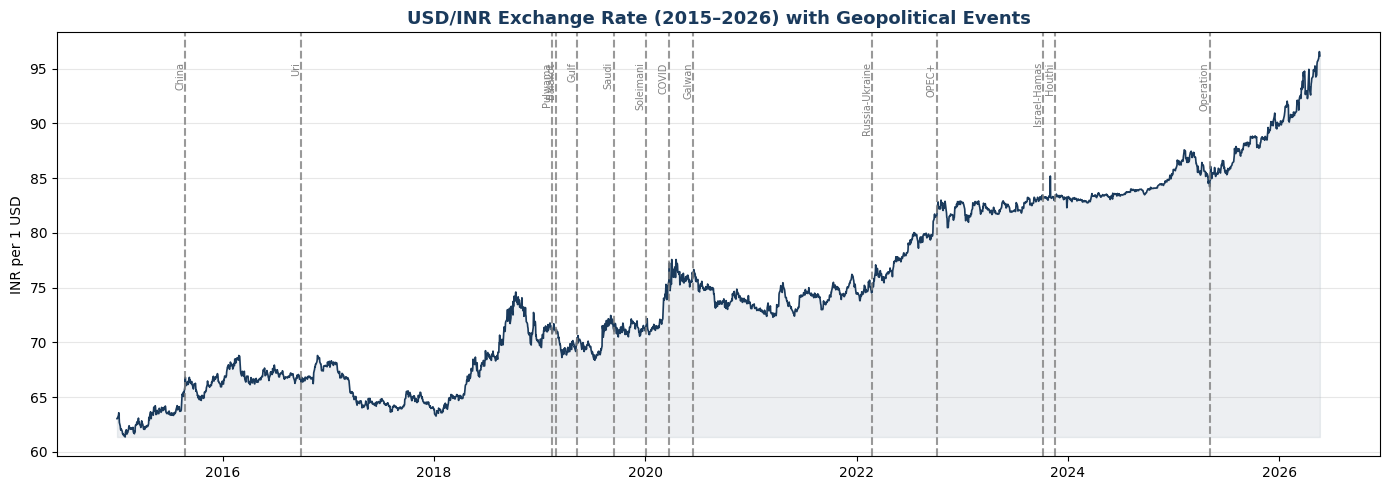

Chart 1 saved.


In [5]:
# ── VISUALIZATION 1: INR TREND WITH EVENT MARKERS ──────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["USDINR"], color="#1A3A5C", linewidth=1.2, label="USD/INR")
ax.fill_between(df.index, df["USDINR"], df["USDINR"].min(), alpha=0.08, color="#1A3A5C")

# Mark events
colors = {"India-Pak Military":"#D62828","India-Pak Tension":"#F77F00",
          "India-China Military":"#9B2226","Global Geopolitical":"#6A0572"}
for _, row in events.iterrows():
    ax.axvline(row["date"], color=colors.get(row["category"],"gray"), 
               linewidth=1.5, linestyle="--", alpha=0.8)
    ax.text(row["date"], df["USDINR"].max()*0.99, 
            row["event"].split()[0], rotation=90, 
            fontsize=7, va="top", ha="right", color=colors.get(row["category"],"gray"))

ax.set_title("USD/INR Exchange Rate (2015–2026) with Geopolitical Events", 
             fontsize=13, fontweight="bold", color="#1A3A5C")
ax.set_ylabel("INR per 1 USD")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/inr_trend_events.png", dpi=150)
plt.show()
print("Chart 1 saved.")

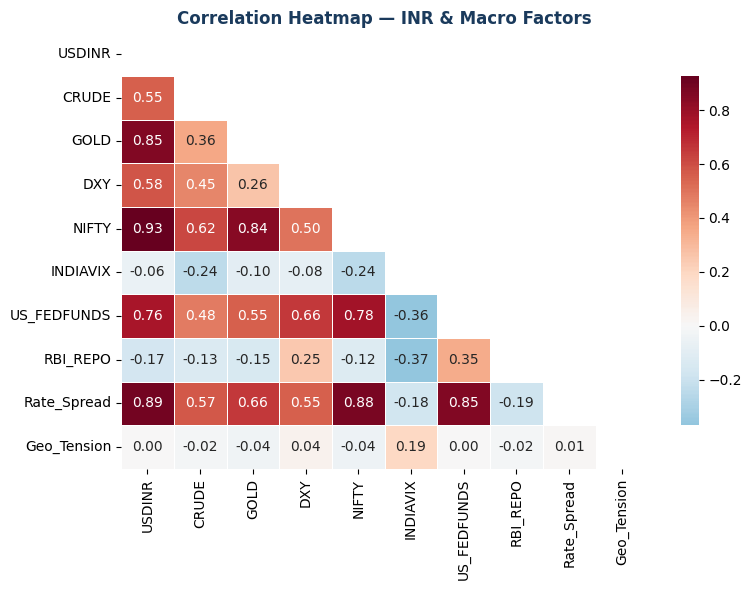

Chart 2 saved.


In [6]:
# ── VISUALIZATION 2: CORRELATION HEATMAP ───────────────
corr_cols = ["USDINR","CRUDE","GOLD","DXY","NIFTY","INDIAVIX",
             "US_FEDFUNDS","RBI_REPO","Rate_Spread","Geo_Tension"]
corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", 
            cmap="RdBu_r", center=0, ax=ax, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — INR & Macro Factors", 
             fontsize=12, fontweight="bold", color="#1A3A5C")
plt.tight_layout()
plt.savefig("../data/processed/correlation_heatmap.png", dpi=150)
plt.show()
print("Chart 2 saved.")

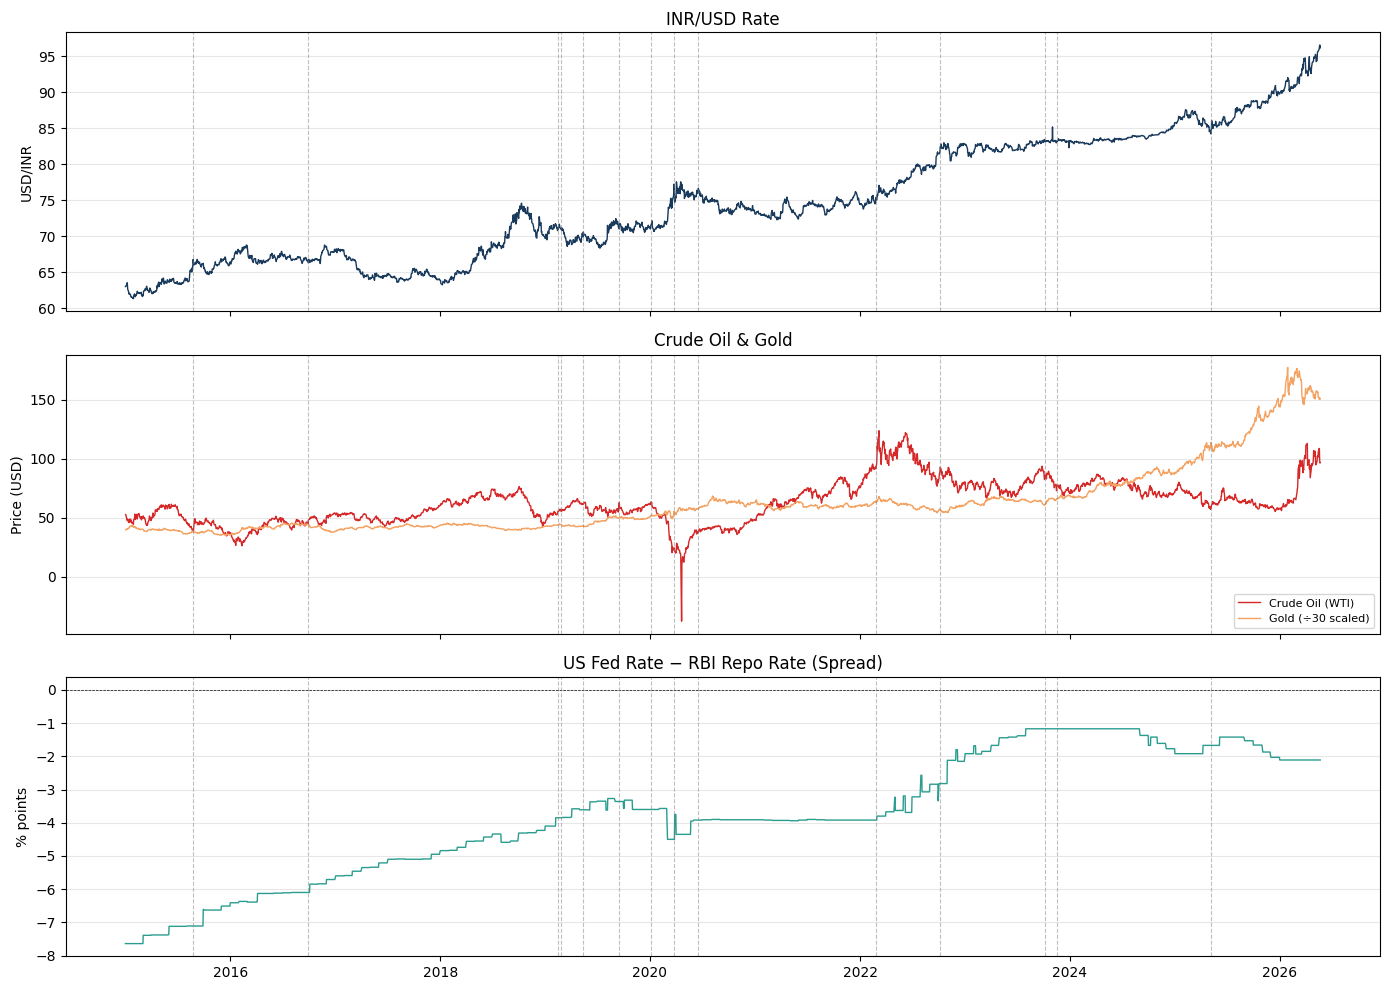

Chart 3 saved. EDA complete!


In [7]:
# ── VISUALIZATION 3: MACRO FACTOR TRENDS ───────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["USDINR"], color="#1A3A5C", linewidth=1)
axes[0].set_ylabel("USD/INR"); axes[0].set_title("INR/USD Rate")

axes[1].plot(df.index, df["CRUDE"], color="#D62828", linewidth=1, label="Crude Oil (WTI)")
axes[1].plot(df.index, df["GOLD"]/30, color="#F4A261", linewidth=1, label="Gold (÷30 scaled)")
axes[1].set_ylabel("Price (USD)"); axes[1].legend(fontsize=8); axes[1].set_title("Crude Oil & Gold")

axes[2].plot(df.index, df["Rate_Spread"], color="#2A9D8F", linewidth=1)
axes[2].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[2].set_ylabel("% points"); axes[2].set_title("US Fed Rate − RBI Repo Rate (Spread)")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    for _, row in events.iterrows():
        ax.axvline(row["date"], color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/macro_trends.png", dpi=150)
plt.show()
print("Chart 3 saved. EDA complete!")